# 3. Mushroom foraging

In this assignment I classify mushrooms as edible or poisonous.

This is a binary classification problem because the target variable has two classes:
- edible
- poisonous

The main focus is data preparation, Logistic Regression, validation methods and classification metrics.

Methods used:
- handling missing values
- one-hot encoding
- scaling
- train/validation/test split
- Logistic Regression
- confusion matrix
- precision, recall, F1 score and accuracy
- ROC curve and precision-recall curve
- cross-validation
- Leave-One-Out cross-validation

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score ,confusion_matrix, precision_recall_curve, roc_curve, classification_report , auc
from sklearn.model_selection import cross_val_score
import seaborn as sns
pd.set_option('display.max_columns', 1000)
df = pd.read_csv('secondary_data.csv', delimiter = ';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


# Data preparation

The dataset needs preprocessing before it can be used for Logistic Regression.  
I handle missing values, encode categorical variables and scale numerical variables.

In [2]:
# Drop columns with a very high percentage of missing values (20% or more)
df_dropped = df.drop(columns=['veil-type','spore-print-color','veil-color','stem-root','gill-spacing','cap-surface','stem-surface'])
missing_percent = df_dropped.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

gill-attachment         16.184971
ring-type                4.046243
cap-diameter             0.000000
cap-shape                0.000000
cap-color                0.000000
class                    0.000000
does-bruise-or-bleed     0.000000
gill-color               0.000000
stem-width               0.000000
stem-height              0.000000
stem-color               0.000000
has-ring                 0.000000
habitat                  0.000000
season                   0.000000
dtype: float64

In [3]:
# split the data into training, validation and testing sets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
X = df_dropped.drop(columns=["class"])
y = df_dropped["class"]
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [4]:
# Order columns by data numeric = columns with numbers, categorical = columns with strings , binary = columns with true or false
numerical_cols = ['cap-diameter', 'stem-width', 'stem-height']
categorical_cols = ['cap-shape','cap-color', 'gill-color'
    ,'gill-attachment','stem-color','ring-type','habitat','season']
binary_cols = ['does-bruise-or-bleed','has-ring']

medians = X_train[numerical_cols].median()
modes = X_train[categorical_cols].mode()

# Scale the numeric data:
scaler = StandardScaler()
scaler.fit(X_train[numerical_cols])

StandardScaler()

### Preprocessing function
I use a helper function so the same preprocessing steps can be applied to training, validation and test data.
This also helps avoid data leakage, because medians, modes and scaler are calculated only from the training data.

In [5]:
def preprocess_data (dataframe, medians, modes, scaler , train_cols= None):
    df = dataframe.copy()
    
    # Fill missing numerical values with training medians
    df[numerical_cols] = df[numerical_cols].fillna(medians)
    
    # Fill missing categorical values with training modes
    df[categorical_cols] = df[categorical_cols].fillna(modes)

    # Map binary to 0s and 1s
    df[binary_cols] = df[binary_cols].replace({'f': 0, 't': 1}).astype(int)

    # One-hot encode categorical columns
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # Scale the numeric data:
    df[numerical_cols] = scaler.transform(df[numerical_cols]) 

    # Align columns to train_cols to make sure the order is the same
    if train_cols is not None:
        df = df.reindex(columns=train_cols, fill_value=0)

    return df

In [6]:
# Preprocess the data
X_train_processed = preprocess_data(X_train, medians, modes, scaler)
training_cols = X_train_processed.columns
X_val_processed = preprocess_data(X_val, medians, modes, scaler, training_cols)
X_test_processed = preprocess_data(X_test, medians, modes, scaler, training_cols)

# Map the labels
y_train_processed = y_train.replace({ 'e': 0, 'p': 1}).astype(int)
y_val_processed = y_val.replace({ 'e': 0, 'p': 1}).astype(int)
y_test_processed = y_test.replace({ 'e': 0, 'p': 1}).astype(int)
X_train_processed

,cap-diameter,does-bruise-or-bleed,stem-height,stem-width,has-ring,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,gill-color_e,gill-color_f,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_p,gill-attachment_s,gill-attachment_x,stem-color_e,stem-color_f,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_p,ring-type_r,ring-type_z,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w
48230,0.323403,0,0.392068,-0.379743,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False
8570,-0.115871,0,0.041894,-0.227008,0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
57241,-1.005929,0,-0.802117,-1.082522,0,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
28794,-0.058324,1,-0.430992,-0.444630,0,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
52015,0.175700,1,1.463543,1.396173,0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54933,-0.789169,0,-0.065853,-0.554439,0,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
30502,0.396296,1,-0.317260,0.502725,0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

# 3. Logistic regression
I use Logistic Regression as a simple and interpretable model for binary classification.

In this notebook:
- `0` means edible
- `1` means poisonous

So: positive = poisonous, negative = edible

class_weight has been used to minimize false negatives, predicting eatable when the mushroom is poisonous is much worse. So we penalize more heavily than if we classify edible ones as poisonous

In [7]:
# Train Logistic Regression
# The poisonous class has higher weight because false negatives are dangerous
log_reg = LogisticRegression(class_weight={0:1,1:5} ,max_iter=1000)
log_reg.fit(X_train_processed, y_train_processed)

# Predict on the val set
y_val_pred = log_reg.predict(X_val_processed)
val_accuracy = accuracy_score(y_val_processed, y_val_pred)
val_precision = precision_score(y_val_processed, y_val_pred)
val_recall = recall_score(y_val_processed, y_val_pred)
val_f1 = f1_score(y_val_processed, y_val_pred)

# Predict on the train set
y_train_pred = log_reg.predict(X_train_processed)
train_accuracy = accuracy_score(y_train_processed, y_train_pred)
train_precision = precision_score(y_train_processed, y_train_pred)
train_recall = recall_score(y_train_processed, y_train_pred)
train_f1 = f1_score(y_train_processed, y_train_pred)

print(f"Validation set - Accuracy: {val_accuracy:.2f}, Precision: {val_precision:.2f}, Recall: {val_recall:.2f}, F1 score: {val_f1:.2f}")
print(f"Train set - Accuracy: {train_accuracy:.2f}, Precision: {train_precision:.2f}, Recall: {train_recall:.2f}, F1 score: {train_f1:.2f}")

Validation set - Accuracy: 0.63, Precision: 0.60, Recall: 0.99, F1 score: 0.75
Train set - Accuracy: 0.64, Precision: 0.61, Recall: 0.99, F1 score: 0.75


### Confusion matrix

The confusion matrix shows the number of correct and incorrect predictions for each class.
In this problem, false negatives are especially dangerous because they mean that a poisonous mushroom was predicted as edible.


Confusion Matrix Train:


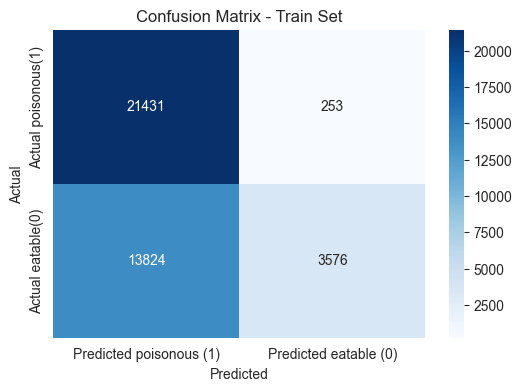

In [8]:
print("\nConfusion Matrix Train:")
conf_matrix_val = confusion_matrix(y_train_processed, y_train_pred, labels=[1, 0])
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_val, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted poisonous (1)", "Predicted eatable (0)"], yticklabels=["Actual poisonous(1)", "Actual eatable(0)"])
plt.title("Confusion Matrix - Train Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Confusion Matrix Validation:


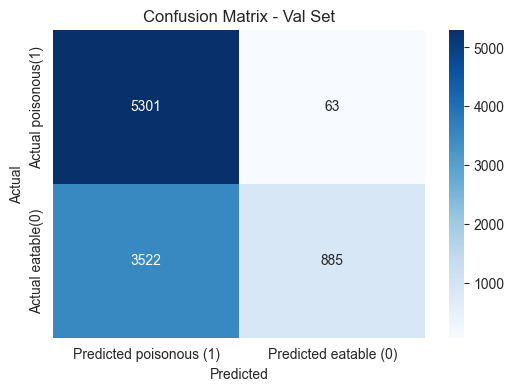

In [9]:
print("\nConfusion Matrix Validation:")
conf_matrix_val = confusion_matrix(y_val_processed, y_val_pred, labels=[1, 0])
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_val, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted poisonous (1)", "Predicted eatable (0)"], yticklabels=["Actual poisonous(1)", "Actual eatable(0)"])
plt.title("Confusion Matrix - Val Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Precision-Recall curve
Since false negatives are critical, recal is especially important. A low recall would mean that the model misses poisonous mushrooms and classifies them as edible.
The curve highlights how precision decreases as recall increases, indicating a trade-off between finding more edible mushrooms and avoiding dangerous mistakes.


### ROC curve
The ROC curve illustrates the trade-off between true positive rate and false positive rate.
A high area under the curve (AUC) indicates that the model can effectively distinguish between edible and poisonous mushrooms.


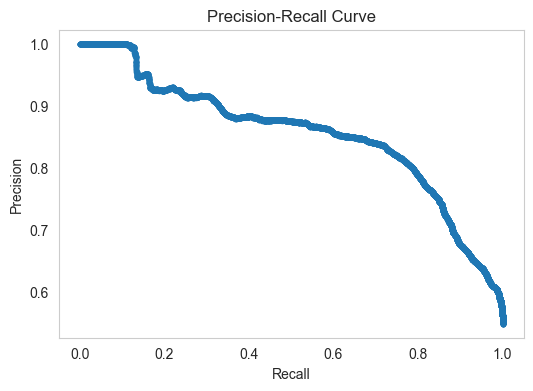

In [10]:
# precision recall curve
y_scores = log_reg.predict_proba(X_val_processed)[:, 1]  # get the predicted probabilities for the positive class
precision, recall, thresholds = precision_recall_curve(y_val_processed, y_scores)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, marker=".")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()

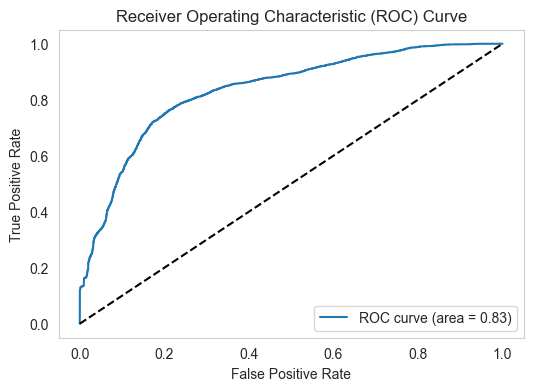

In [11]:
# roc curve
fpr, tpr, thresholds = roc_curve(y_val_processed, y_scores)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")  # dashed diagonal line for random classifier
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Train / Validation / Test split

## Pros
This method is simple and fast.  
It gives a clear separation between training, validation and final testing.

## Cons
The result can depend on the specific split of the data.  
It also uses less data for training compared to cross-validation.

## Test set
The test set should be used only once at the end.  
This helps avoid data leakage and gives a more realistic estimate of final model performance.

In [12]:
# Predict labels for the test set using the trained Logistic Regression model
y_test_pred = log_reg.predict(X_test_processed)

#Test acc, precision, recall and f1 score
test_accuracy = accuracy_score(y_test_processed, y_test_pred)
test_precision = precision_score(y_test_processed, y_test_pred)
test_recall = recall_score(y_test_processed, y_test_pred)
test_f1 = f1_score(y_test_processed, y_test_pred)

print(f"Train set - Accuracy: {train_accuracy:.2f}, Precision: {train_precision:.2f}, Recall: {train_recall:.2f}, F1 score: {train_f1:.2f}")
print(f"Validation set - Accuracy: {val_accuracy:.2f}, Precision: {val_precision:.2f}, Recall: {val_recall:.2f}, F1 score: {val_f1:.2f}")
print(f"Test set - Accuracy: {test_accuracy:.2f}, Precision: {test_precision:.2f}, Recall: {test_recall:.2f}, F1 score: {test_f1:.2f}")

Train set - Accuracy: 0.64, Precision: 0.61, Recall: 0.99, F1 score: 0.75
Validation set - Accuracy: 0.63, Precision: 0.60, Recall: 0.99, F1 score: 0.75
Test set - Accuracy: 0.65, Precision: 0.61, Recall: 0.99, F1 score: 0.76



Confusion Matrix Test:


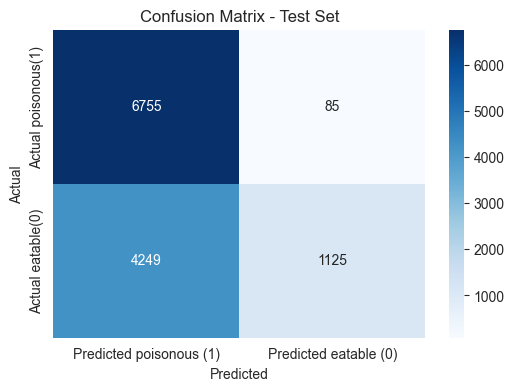

In [13]:
print("\nConfusion Matrix Test:")
conf_matrix_val = confusion_matrix(y_test_processed, y_test_pred, labels=[1, 0])
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_val, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted poisonous (1)", "Predicted eatable (0)"], yticklabels=["Actual poisonous(1)", "Actual eatable(0)"])
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

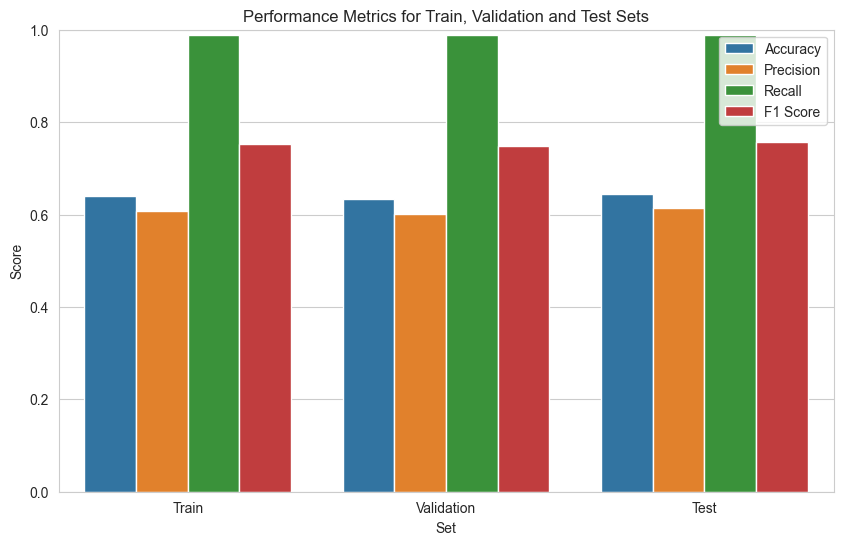

In [14]:
# plot the accuracy, precision, recall and F1 score for train, validation and test sets
metrics_df = pd.DataFrame({
    "Set": ["Train", "Validation", "Test"],
    "Accuracy": [train_accuracy, val_accuracy, test_accuracy],
    "Precision": [train_precision, val_precision, test_precision],
    "Recall": [train_recall, val_recall, test_recall],
    "F1 Score": [train_f1, val_f1, test_f1]
})
metrics_df_melted = metrics_df.melt(id_vars="Set", var_name="Metric", value_name="Score")
plt.figure(figsize=(10, 6))
sns.barplot(x="Set", y="Score", hue="Metric", data=metrics_df_melted)
plt.title("Performance Metrics for Train, Validation and Test Sets")
plt.ylim(0, 1)
plt.legend(loc="upper right")
plt.show()

# Cross-validation

## Pros
Cross-validation gives a more reliable estimate of model performance because the model is trained and validated on several different splits.

## Cons
It is more computationally expensive than a simple train/validation/test split, especially with large datasets.

In [15]:
print("\nClassification Report:")
print(classification_report(y_val_processed, y_val_pred))

cv_scores = cross_val_score(log_reg, X_train_processed, y_train_processed, cv=5)

print("\nCross-validation accuracy:", cv_scores.mean())


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.20      0.33      4407
           1       0.60      0.99      0.75      5364

    accuracy                           0.63      9771
   macro avg       0.77      0.59      0.54      9771
weighted avg       0.75      0.63      0.56      9771


Cross-validation accuracy: 0.6393919755240429


### Metric decision

To reduce the risk of false negatives, we prioritize recall for the poisonous class.  
This may reduce precision, but in this case safety is more important than classifying every edible mushroom correctly.

# Leave-One-Out Cross-Validation

## Pros
Leave-One-Out uses almost all data for training in each iteration, so it can be useful for very small datasets.

## Cons
It is computationally expensive because the model is trained once for each data point.  
It can also have high variance because the training sets are very similar.

In this notebook, I use only a sample of 100 rows because LOOCV would be too slow on the full dataset.
The model performs better on the test set than during LOOCV. This may be caused by the small sample size and the high variance of LOOCV.

In [16]:
from sklearn.model_selection import LeaveOneOut

# Sample 100 rows because LOOCV is computationally expensive.
sample_idx = X_train_processed.sample(n=100, random_state=42).index
X_small = X_train_processed.loc[sample_idx]
y_small = y_train_processed.loc[sample_idx]

# split the data into train and test sets before LOOCV to avoid data leakage
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(X_small, y_small, test_size=0.2, random_state=42)
loo = LeaveOneOut()
loo_scores = cross_val_score(log_reg, X_train_small, y_train_small, cv=loo)
print(f"LOOCV scores: {loo_scores}")
print(f"Mean LOOCV score: {loo_scores.mean():.2f}")

LOOCV scores: [0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 0.
 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0.
 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0.
 0. 1. 0. 1. 1. 1. 0. 0.]
Mean LOOCV score: 0.60


In [17]:
# evaluate the model on the test set after LOOCV
log_reg.fit(X_train_small, y_train_small)
test_accuracy_loo = log_reg.score(X_test_small, y_test_small)
print(f"Test set accuracy after LOOCV: {test_accuracy_loo:.2f}")

Test set accuracy after LOOCV: 0.75


# Discussion about performance metric

The most relevant metric for this problem is recall

This is because a false negative means that a poisonous mushroom is classified as edible, which is the most dangerous error in this use case.

Accuracy alone is not enough because it treats all mistakes equally. In this problem, different mistakes have different consequences.

Precision is also useful, because it tells how many mushrooms predicted as poisonous actually were poisonous. 

F1 score is useful as a balance between precision and recall, but if I must choose one main metric, I would prioritize recall for the poisonous class.

## Final conclusion

This assignment focused on binary classification of mushrooms as edible or poisonous.

The most important part was data preparation. I removed columns with too many missing values, imputed remaining missing values, one-hot encoded categorical variables and scaled numerical features.

I used Logistic Regression because it is a simple and interpretable classification model.

The positive class was poisonous, so recall for the poisonous class was the most important metric. This is because false negatives are dangerous: a poisonous mushroom predicted as edible could have serious consequences.

I compared model performance using train, validation and test sets, confusion matrices, precision, recall, F1 score, ROC curve, precision-recall curve, cross-validation and Leave-One-Out CV.

A limitation is that Logistic Regression is a linear model, so it may not capture all complex relationships in the mushroom features. A possible improvement would be to test more complex classification models.